# LDA, QDA, and PCA for Audio Classification (Mini Speech Commands)

This EE502 notebook is designed to run **end-to-end in Google Colab**. It will:
- Download the **Mini Speech Commands** dataset (one-second WAV files with spoken keywords).
- **Extract features** from raw audio (MFCCs, Δ-MFCCs, spectral centroid/bandwidth/rolloff, ZCR, RMS, chroma).
- **Analyze PCA**: explained variance, cumulative variance, 2D PCA embedding, top-loading features.
- Train **LDA** and **QDA**, both **with and without PCA** (via scikit-learn Pipelines).
- Perform **Grid Search (CV)** for hyperparameters: LDA solver/shrinkage; QDA regularization.
- Evaluate with **accuracy, classification report, confusion matrices, ROC curves (micro/macro)**.

## 1) Setup: Dependencies
Install required packages (librosa for audio, scikit-learn for ML, pandas/matplotlib for analysis).

In [ ]:
# If running in Colab, uncomment the next line.
# !pip install -q librosa soundfile scikit-learn pandas matplotlib tqdm

import os, pathlib, zipfile, warnings, math, itertools, sys
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: make plots a bit larger
plt.rcParams["figure.figsize"] = (8, 5)

# Audio
import librosa
import librosa.feature
import librosa.display

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, auc)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from tqdm import tqdm

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2) Download Mini Speech Commands Dataset
- One-second WAV files organized by label (e.g., `yes`, `no`, `up`, `down`, ...).
- We'll use `wget` to fetch the dataset and unzip it under `data/mini_speech_commands`.

In [ ]:
DATASET_URL = "https://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"
DATA_DIR = pathlib.Path("data/mini_speech_commands")
ZIP_PATH = pathlib.Path("mini_speech_commands.zip")

if not DATA_DIR.exists():
    print("Downloading Mini Speech Commands ...")
    # Fallback logic to avoid failures if !wget is not available
    try:
        import urllib.request
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH.as_posix())
    except Exception as e:
        print("urllib failed, trying wget...", e)
        os.system(f"wget -q {DATASET_URL} -O {ZIP_PATH.as_posix()}")
    print("Unzipping ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall("data")
    print("Done.")

# List classes
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
label_to_index = {name: idx for idx, name in enumerate(class_names)}

audio_files = []
labels = []
for label in class_names:
    for wav in (DATA_DIR/label).glob("*.wav"):
        audio_files.append(str(wav))
        labels.append(label_to_index[label])

audio_files = np.array(audio_files)
labels = np.array(labels)

# Shuffle once for good measure
idx = np.random.permutation(len(audio_files))
audio_files, labels = audio_files[idx], labels[idx]

print(f"Classes ({len(class_names)}):", class_names)
print(f"Total audio files: {len(audio_files)}")

# Summary table (counts per class)
counts = pd.Series(labels).value_counts().sort_index()
summary_df = pd.DataFrame({"label_index": counts.index, "label_name": [class_names[i] for i in counts.index], "count": counts.values})
summary_df

Unzipping ...
Done.
Classes (8): ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']
Total audio files: 8000


,label_index,label_name,count
0,0,down,1000
1,1,go,1000
2,2,left,1000
3,3,no,1000
4,4,right,1000
5,5,stop,1000
6,6,up,1000
7,7,yes,1000


### Class Distribution
A quick bar chart to visualize how many samples we have for each word.

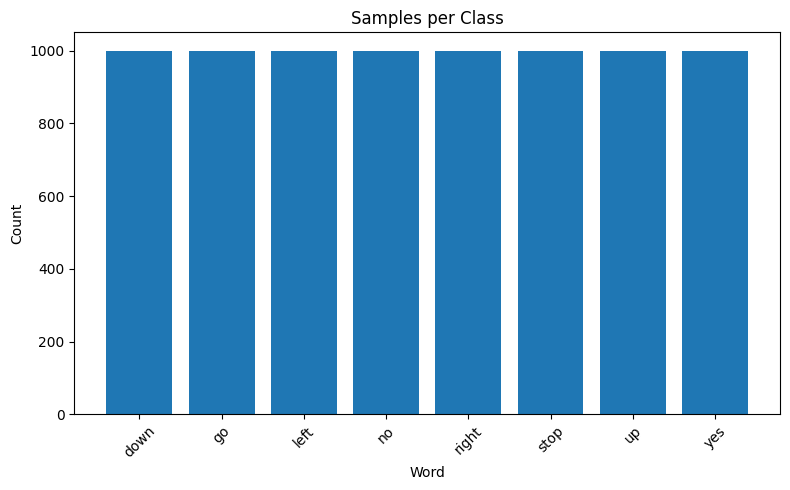

In [ ]:
fig, ax = plt.subplots()
ax.bar(summary_df["label_name"], summary_df["count"])
ax.set_title("Samples per Class")
ax.set_xlabel("Word")
ax.set_ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3) Inspect a Random Example (Waveform + Mel Spectrogram)
This helps confirm sample rate, clip duration (~1s), and see distinct spectral patterns.

Example file: data/mini_speech_commands/yes/1993db46_nohash_0.wav
Label: yes (index=7)
Signal shape: (16000,) Sample rate: 16000


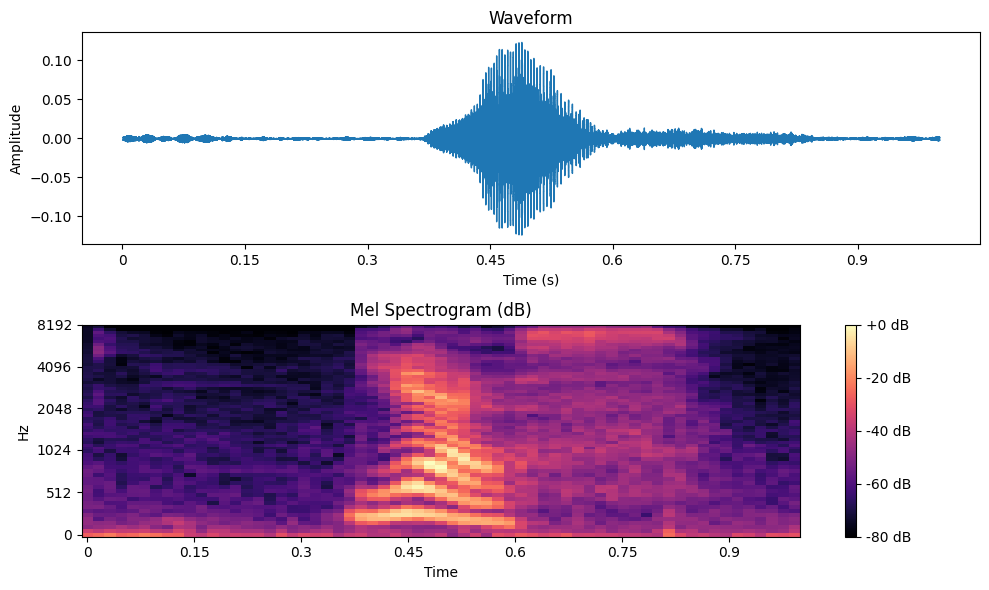

In [ ]:
SR = 16000  # dataset clips are 16 kHz; librosa will resample if not

# Pick a random example
ex_idx = np.random.randint(len(audio_files))
ex_path, ex_label = audio_files[ex_idx], labels[ex_idx]
signal, sr = librosa.load(ex_path, sr=SR)

print("Example file:", ex_path)
print("Label:", class_names[ex_label], f"(index={ex_label})")
print("Signal shape:", signal.shape, "Sample rate:", sr)

# Waveform + Mel
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
librosa.display.waveshow(signal, sr=sr, ax=ax[0])
ax[0].set_title("Waveform")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")

S = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=512, hop_length=256, n_mels=64)
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis="time", y_axis="mel", sr=sr, hop_length=256, ax=ax[1])
ax[1].set_title("Mel Spectrogram (dB)")
fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()

## 4) Feature Extraction (Handcrafted)
We compute an **86-D** feature vector per clip using frame-based analysis and summary stats:

- **MFCCs (13)** + **Δ-MFCCs (13)** → mean & std over time (52 dims)
- **Spectral features**: centroid, bandwidth, rolloff → mean & std (6 dims)
- **Time-domain features**: ZCR, RMS → mean & std (4 dims)
- **Chroma (12)** → mean & std (24 dims)

Total: 52 + 6 + 4 + 24 = **86 features** per clip.

In [ ]:
N_MFCC = 13
N_FFT = 512
HOP = 256
N_MELS = 40

def feature_names():
    names = []
    # MFCC mean/std
    for i in range(1, N_MFCC+1):
        names.append(f"mfcc_mean_{i}")
    for i in range(1, N_MFCC+1):
        names.append(f"mfcc_std_{i}")
    # Delta MFCC mean/std
    for i in range(1, N_MFCC+1):
        names.append(f"dmfcc_mean_{i}")
    for i in range(1, N_MFCC+1):
        names.append(f"dmfcc_std_{i}")
    # Spectral + time-domain
    for base in ["centroid", "bandwidth", "rolloff", "zcr", "rms"]:
        names.append(f"{base}_mean")
        names.append(f"{base}_std")
    # Chroma mean/std
    for i in range(1, 13):
        names.append(f"chroma_mean_{i}")
    for i in range(1, 13):
        names.append(f"chroma_std_{i}")
    return names

FEATURE_NAMES = feature_names()

def extract_features(y, sr=SR):
    '''Return 86-D feature vector for a ~1-second audio clip.'''
    # MFCCs + delta
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS)
    dmfcc = librosa.feature.delta(mfcc)
    # Spectral features
    cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP)
    bw   = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP)
    roll = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP)
    # Time-domain
    zcr  = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP)
    rms  = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP)
    # Chroma
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP)

    # Aggregate mean/std
    feats = []
    feats.extend(np.mean(mfcc, axis=1));   feats.extend(np.std(mfcc, axis=1))
    feats.extend(np.mean(dmfcc, axis=1));  feats.extend(np.std(dmfcc, axis=1))
    for F in [cent, bw, roll, zcr, rms]:
        feats.append(np.mean(F)); feats.append(np.std(F))
    feats.extend(np.mean(chroma, axis=1)); feats.extend(np.std(chroma, axis=1))
    return np.array(feats, dtype=np.float32)

# Extract features (takes a few minutes)
X = []
y = labels.copy()
print("Extracting features ...")
for fp in tqdm(audio_files, total=len(audio_files)):
    sig, _ = librosa.load(fp, sr=SR)
    X.append(extract_features(sig, sr=SR))
X = np.vstack(X)
print("Feature matrix shape:", X.shape)  # (N, 86)
print("Label vector shape:", y.shape)

# Preview
pd.DataFrame(X[:5], columns=FEATURE_NAMES)

Extracting features ...


100%|██████████| 8000/8000 [02:17<00:00, 58.19it/s]


Feature matrix shape: (8000, 86)
Label vector shape: (8000,)


,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,mfcc_mean_10,...,chroma_std_3,chroma_std_4,chroma_std_5,chroma_std_6,chroma_std_7,chroma_std_8,chroma_std_9,chroma_std_10,chroma_std_11,chroma_std_12
0,-295.788544,51.178089,2.940863,17.856562,-5.187170,-12.137442,-10.457468,-5.154897,-6.377697,-2.934245,...,0.209306,0.342374,0.352593,0.327758,0.315939,0.352696,0.319751,0.288759,0.316179,0.333133
1,-257.838379,71.398949,12.719646,16.713614,0.428551,11.331009,-1.164129,6.455015,2.813860,7.874049,...,0.187209,0.194482,0.217069,0.213581,0.201380,0.202597,0.190079,0.176024,0.213391,0.283777
2,-261.456879,59.814594,5.702281,15.151422,2.546148,5.704401,1.111038,-2.206015,-0.313145,-1.885535,...,0.304004,0.305568,0.310329,0.272268,0.295832,0.310501,0.271414,0.307016,0.317276,0.267782
3,-303.171478,81.432312,13.544183,9.071783,-9.188061,4.091760,-1.733929,-0.228083,-1.256287,1.244395,...,0.237312,0.251785,0.239001,0.245464,0.252526,0.226289,0.230204,0.246682,0.229639,0.254263
4,-368.168030,22.566160,-4.380904,11.400381,-15.427134,-8.462079,-10.978666,4.220098,-3.675551,-5.821417,...,0.256732,0.368584,0.298735,0.331582,0.295726,0.334084,0.284615,0.267409,0.280285,0.300962


## 5) Split Data (Stratified Train/Test)
We hold out **20%** for final testing and use **cross-validation** on the training set for model selection.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (6400, 86) Test shape: (1600, 86)


## 6) PCA Analysis (on Training Set Only)
We standardize features, fit **PCA** on the **training** set to avoid data leakage, and inspect explained variance.

Components for ~95% variance: 51
Components for ~99% variance: 70


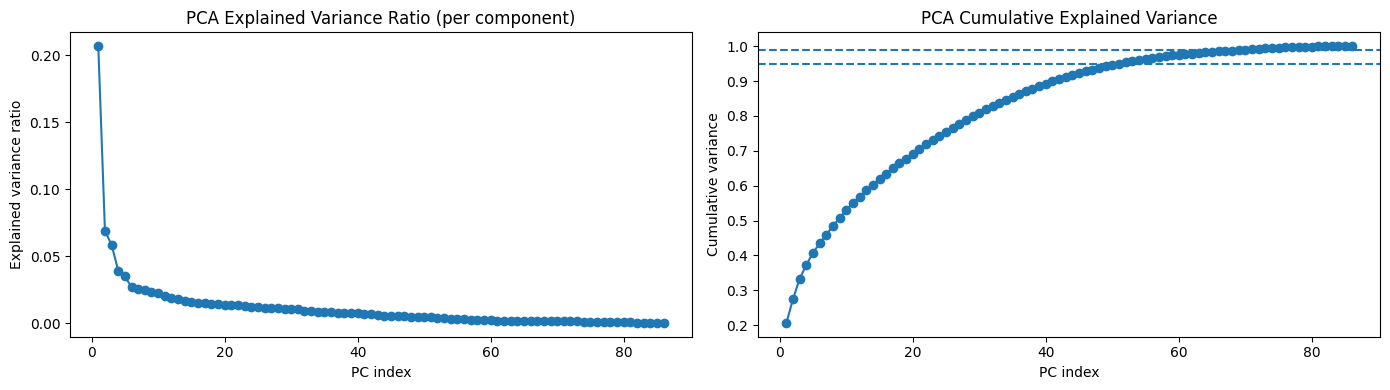

In [ ]:
scaler_for_pca = StandardScaler()
X_train_scaled = scaler_for_pca.fit_transform(X_train)
X_test_scaled  = scaler_for_pca.transform(X_test)

pca_full = PCA().fit(X_train_scaled)
exp_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

k_95 = int(np.argmax(cum_var >= 0.95) + 1)
k_99 = int(np.argmax(cum_var >= 0.99) + 1)
print(f"Components for ~95% variance: {k_95}")
print(f"Components for ~99% variance: {k_99}")

# Scree + cumulative plots
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(np.arange(1, len(exp_var)+1), exp_var, marker='o')
ax[0].set_title("PCA Explained Variance Ratio (per component)")
ax[0].set_xlabel("PC index")
ax[0].set_ylabel("Explained variance ratio")

ax[1].plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
ax[1].axhline(0.95, linestyle='--')
ax[1].axhline(0.99, linestyle='--')
ax[1].set_title("PCA Cumulative Explained Variance")
ax[1].set_xlabel("PC index")
ax[1].set_ylabel("Cumulative variance")

plt.tight_layout()
plt.show()

### 2D PCA Embedding (Visualization)
Project training samples onto the first two PCs to visualize cluster structure by class.

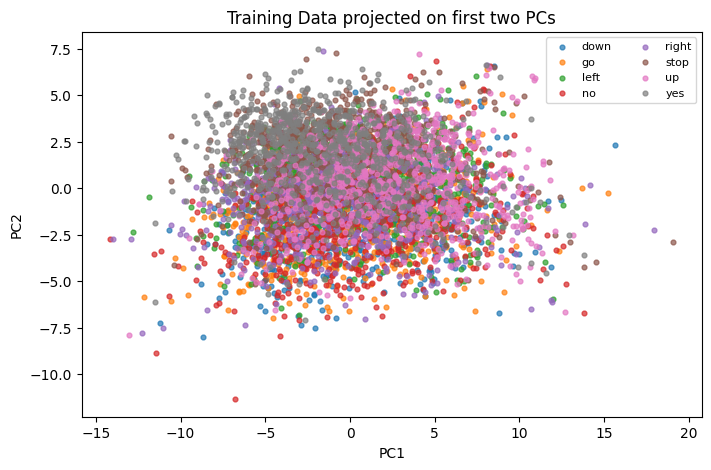

In [ ]:
X_train_pca2 = pca_full.transform(X_train_scaled)[:, :2]

fig, ax = plt.subplots()
for li in np.unique(y_train):
    ix = (y_train == li)
    ax.scatter(X_train_pca2[ix, 0], X_train_pca2[ix, 1], s=12, alpha=0.7, label=class_names[li])
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Training Data projected on first two PCs")
ax.legend(loc="best", ncol=2, fontsize=8)
plt.show()

### Which Original Features Contribute Most to PC1/PC2?
We inspect PCA loadings to see top contributing features to PC1 and PC2.

In [ ]:
# Loadings (components) shape: [n_components, n_features]
loadings = pca_full.components_  # rows are PCs, cols correspond to FEATURE_NAMES after scaling

def top_loading_table(pc_idx=0, top_k=12):
    coefs = loadings[pc_idx, :]
    order = np.argsort(np.abs(coefs))[::-1][:top_k]
    df = pd.DataFrame({
        "feature": [FEATURE_NAMES[i] for i in order],
        "loading": coefs[order]
    })
    return df

print("Top loading features for PC1:")
top_loading_table(0, 12)

Top loading features for PC1:


,feature,loading
0,chroma_mean_1,0.168634
1,chroma_mean_12,0.166108
2,chroma_mean_11,0.164662
3,chroma_mean_2,0.163703
4,chroma_mean_10,0.157434
5,chroma_mean_3,0.155689
6,chroma_std_6,-0.150399
7,chroma_mean_9,0.147970
8,chroma_std_5,-0.147806
9,chroma_std_7,-0.144108


## 7) Model Pipelines and Grid Search
We compare **LDA** and **QDA**:
- **Without PCA**: `StandardScaler -> Classifier`
- **With PCA**: `StandardScaler -> PCA(n_components in {0.90, 0.95, 0.99}) -> Classifier`

**Hyperparameters** (Grid Search 5-fold CV):
- **LDA**: try `solver='svd'` (no shrinkage) and `solver in {'lsqr','eigen'} + shrinkage='auto'` (regularized LDA).
- **QDA**: try `reg_param` over a range (e.g., 0.0 to 0.9).

We use **StratifiedKFold** to preserve class balance across folds.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# Pipelines
pipe_lda_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

pipe_qda_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("qda", QuadraticDiscriminantAnalysis())
])

pipe_lda_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(svd_solver="full")),    # allow float n_components as variance ratio
    ("lda", LinearDiscriminantAnalysis())
])

pipe_qda_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(svd_solver="full")),
    ("qda", QuadraticDiscriminantAnalysis())
])

# Parameter grids
param_lda_no_pca = [
    {"lda__solver": ["svd"]},
    {"lda__solver": ["lsqr"], "lda__shrinkage": ["auto"]},
    {"lda__solver": ["eigen"], "lda__shrinkage": ["auto"]},
]

param_qda_no_pca = {
    "qda__reg_param": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
}

param_lda_pca = [
    {"pca__n_components": [0.90, 0.95, 0.99], "lda__solver": ["svd"]},
    {"pca__n_components": [0.90, 0.95, 0.99], "lda__solver": ["lsqr"], "lda__shrinkage": ["auto"]},
    {"pca__n_components": [0.90, 0.95, 0.99], "lda__solver": ["eigen"], "lda__shrinkage": ["auto"]},
]

param_qda_pca = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "qda__reg_param": [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
}

# Grid searches
grid_lda_no_pca = GridSearchCV(
    pipe_lda_no_pca, param_lda_no_pca, cv=cv, scoring="accuracy", n_jobs=-1
)
grid_qda_no_pca = GridSearchCV(
    pipe_qda_no_pca, param_qda_no_pca, cv=cv, scoring="accuracy", n_jobs=-1, error_score=np.nan
)
grid_lda_pca = GridSearchCV(
    pipe_lda_pca, param_lda_pca, cv=cv, scoring="accuracy", n_jobs=-1
)
grid_qda_pca = GridSearchCV(
    pipe_qda_pca, param_qda_pca, cv=cv, scoring="accuracy", n_jobs=-1, error_score=np.nan
)

print("Running grid searches (this may take a few minutes) ...")
grid_lda_no_pca.fit(X_train, y_train)
grid_qda_no_pca.fit(X_train, y_train)
grid_lda_pca.fit(X_train, y_train)
grid_qda_pca.fit(X_train, y_train)

def cv_summary(gs, name):
    df = pd.DataFrame(gs.cv_results_)
    keep_cols = [c for c in df.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score", "rank_test_score"]
    df = df[keep_cols].sort_values("rank_test_score")
    df.insert(0, "model", name)
    return df

cv_table = pd.concat([
    cv_summary(grid_lda_no_pca, "LDA_noPCA"),
    cv_summary(grid_qda_no_pca, "QDA_noPCA"),
    cv_summary(grid_lda_pca, "LDA_PCA"),
    cv_summary(grid_qda_pca, "QDA_PCA"),
], ignore_index=True)

print("Best params / CV accuracy:")
for name, gs in [("LDA_noPCA", grid_lda_no_pca), ("QDA_noPCA", grid_qda_no_pca),
                 ("LDA_PCA", grid_lda_pca), ("QDA_PCA", grid_qda_pca)]:
    print(f"  {name:10s} | best={gs.best_params_} | CV acc={gs.best_score_:.4f}")

cv_table.head(12)

Running grid searches (this may take a few minutes) ...
Best params / CV accuracy:
  LDA_noPCA  | best={'lda__solver': 'svd'} | CV acc=0.7123
  QDA_noPCA  | best={'qda__reg_param': 0.05} | CV acc=0.6620
  LDA_PCA    | best={'lda__solver': 'svd', 'pca__n_components': 0.99} | CV acc=0.6639
  QDA_PCA    | best={'pca__n_components': 0.99, 'qda__reg_param': 0.2} | CV acc=0.6327


,model,param_lda__solver,param_lda__shrinkage,mean_test_score,std_test_score,rank_test_score,param_qda__reg_param,param_pca__n_components
0,LDA_noPCA,svd,NaN,0.712344,0.013634,1,NaN,NaN
1,LDA_noPCA,lsqr,auto,0.704219,0.015322,2,NaN,NaN
2,LDA_noPCA,eigen,auto,0.704219,0.015322,2,NaN,NaN
3,QDA_noPCA,NaN,NaN,0.662031,0.009265,1,0.05,NaN
4,QDA_noPCA,NaN,NaN,0.657813,0.012529,2,0.20,NaN
5,QDA_noPCA,NaN,NaN,0.657344,0.011165,3,0.10,NaN
6,QDA_noPCA,NaN,NaN,0.649062,0.009380,4,0.30,NaN
7,QDA_noPCA,NaN,NaN,0.644844,0.008998,5,0.00,NaN
8,QDA_noPCA,NaN,NaN,0.641875,0.011510,6,0.50,NaN
9,QDA_noPCA,NaN,NaN,0.626719,0.019612,7,0.70,NaN


### CV Summary (Top Rows)
The table includes tried hyperparameters and cross-validated mean/stdev accuracy.

In [ ]:
cv_table.head(12)

,model,param_lda__solver,param_lda__shrinkage,mean_test_score,std_test_score,rank_test_score,param_qda__reg_param,param_pca__n_components
0,LDA_noPCA,svd,NaN,0.712344,0.013634,1,NaN,NaN
1,LDA_noPCA,lsqr,auto,0.704219,0.015322,2,NaN,NaN
2,LDA_noPCA,eigen,auto,0.704219,0.015322,2,NaN,NaN
3,QDA_noPCA,NaN,NaN,0.662031,0.009265,1,0.05,NaN
4,QDA_noPCA,NaN,NaN,0.657813,0.012529,2,0.20,NaN
5,QDA_noPCA,NaN,NaN,0.657344,0.011165,3,0.10,NaN
6,QDA_noPCA,NaN,NaN,0.649062,0.009380,4,0.30,NaN
7,QDA_noPCA,NaN,NaN,0.644844,0.008998,5,0.00,NaN
8,QDA_noPCA,NaN,NaN,0.641875,0.011510,6,0.50,NaN
9,QDA_noPCA,NaN,NaN,0.626719,0.019612,7,0.70,NaN


## 8) Final Evaluation on Test Set
We refit each best model on the full training set and evaluate on the held-out test set.
We report **accuracy**, **classification report**, and **confusion matrix**.

In [ ]:
best_models = {
    "LDA_noPCA": grid_lda_no_pca.best_estimator_,
    "QDA_noPCA": grid_qda_no_pca.best_estimator_,
    "LDA_PCA": grid_lda_pca.best_estimator_,
    "QDA_PCA": grid_qda_pca.best_estimator_,
}

# Fit best models on the full training data (GridSearchCV already refits by default, but do it explicitly)
for k, m in best_models.items():
    m.fit(X_train, y_train)

# Collect metrics
results_rows = []
reports = {}
conf_mats = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results_rows.append({"model": name, "test_accuracy": acc})
    reports[name] = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    conf_mats[name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results_rows).sort_values("test_accuracy", ascending=False)
results_df

,model,test_accuracy
0,LDA_noPCA,0.705000
1,QDA_noPCA,0.672500
2,LDA_PCA,0.661875
3,QDA_PCA,0.641250


### Classification Reports (per model)
Precision, recall, F1-score per class and averages.

In [ ]:
def report_to_df(report_dict):
    df = pd.DataFrame(report_dict).T
    cols = [c for c in ["precision", "recall", "f1-score", "support"] if c in df.columns]
    return df[cols]

for name in best_models.keys():
    print(f"=== {name} ===")
    display(report_to_df(reports[name]))

=== LDA_noPCA ===


,precision,recall,f1-score,support
down,0.675258,0.655,0.664975,200.000
go,0.597087,0.615,0.605911,200.000
left,0.607843,0.620,0.613861,200.000
no,0.579487,0.565,0.572152,200.000
right,0.708738,0.730,0.719212,200.000
stop,0.821053,0.780,0.800000,200.000
up,0.771689,0.845,0.806683,200.000
yes,0.892473,0.830,0.860104,200.000
accuracy,0.705000,0.705,0.705000,0.705
macro avg,0.706704,0.705,0.705362,1600.000


=== QDA_noPCA ===


,precision,recall,f1-score,support
down,0.673797,0.6300,0.651163,200.0000
go,0.558952,0.6400,0.596737,200.0000
left,0.645503,0.6100,0.627249,200.0000
no,0.502703,0.4650,0.483117,200.0000
right,0.678049,0.6950,0.686420,200.0000
stop,0.783920,0.7800,0.781955,200.0000
up,0.680751,0.7250,0.702179,200.0000
yes,0.865285,0.8350,0.849873,200.0000
accuracy,0.672500,0.6725,0.672500,0.6725
macro avg,0.673620,0.6725,0.672337,1600.0000


=== LDA_PCA ===


,precision,recall,f1-score,support
down,0.623762,0.630000,0.626866,200.000000
go,0.535000,0.535000,0.535000,200.000000
left,0.560000,0.560000,0.560000,200.000000
no,0.530055,0.485000,0.506527,200.000000
right,0.680365,0.745000,0.711217,200.000000
stop,0.801075,0.745000,0.772021,200.000000
up,0.699115,0.790000,0.741784,200.000000
yes,0.875000,0.805000,0.838542,200.000000
accuracy,0.661875,0.661875,0.661875,0.661875
macro avg,0.663047,0.661875,0.661495,1600.000000


=== QDA_PCA ===


,precision,recall,f1-score,support
down,0.618557,0.60000,0.609137,200.00000
go,0.561905,0.59000,0.575610,200.00000
left,0.583784,0.54000,0.561039,200.00000
no,0.483696,0.44500,0.463542,200.00000
right,0.685279,0.67500,0.680101,200.00000
stop,0.733990,0.74500,0.739454,200.00000
up,0.602564,0.70500,0.649770,200.00000
yes,0.860104,0.83000,0.844784,200.00000
accuracy,0.641250,0.64125,0.641250,0.64125
macro avg,0.641235,0.64125,0.640429,1600.00000


### Confusion Matrices
Visualize confusion matrices for each model (darker diagonal = better).

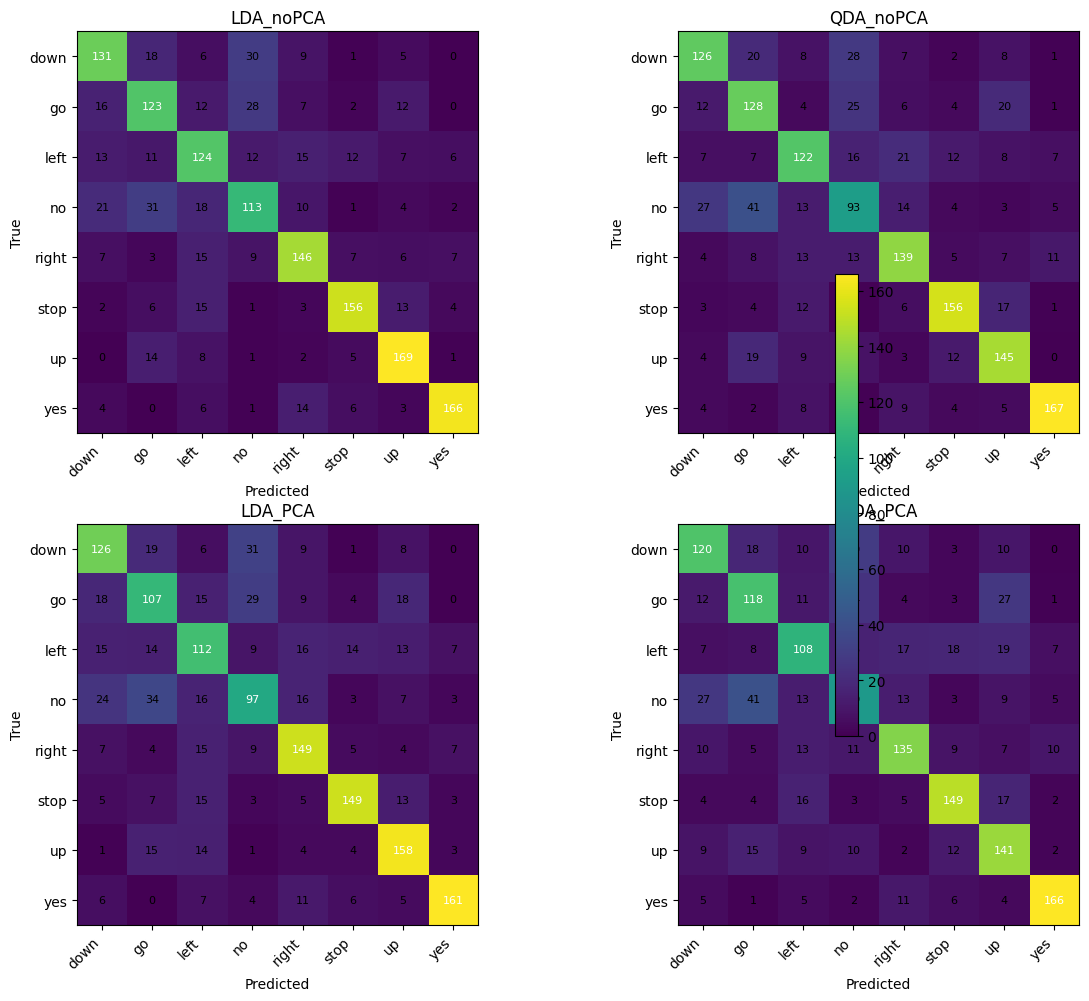

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for ax, (name, cm) in zip(axes, conf_mats.items()):
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(name)
    ax.set_xticks(np.arange(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(class_names))); ax.set_yticklabels(class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()*0.6 else "black", fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
fig.colorbar(im, ax=axes.tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

## 9) ROC Curves (Multi-class)
We compute **micro-averaged** ROC curves using one-vs-rest (OvR) scores.

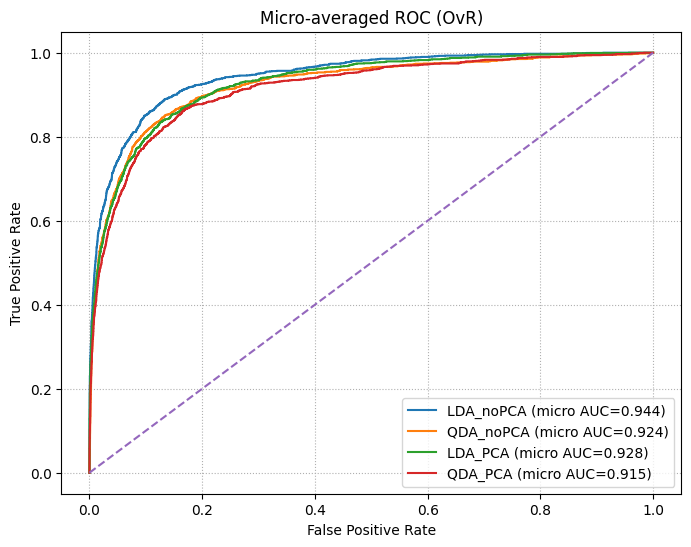

In [ ]:
# Binarize labels for ROC
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

def proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    elif hasattr(model, "decision_function"):
        s = model.decision_function(X)
        # Normalize to [0,1] for ROC computation consistency
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
        return scaler.fit_transform(s)
    else:
        return None

plt.figure(figsize=(8,6))
for name, model in best_models.items():
    scores = proba(model, X_test)
    if scores is None:
        print(f"{name} does not provide scores; skipping ROC.")
        continue
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), scores.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, label=f"{name} (micro AUC={roc_auc_micro:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-averaged ROC (OvR)")
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

## 10) Was PCA Necessary?
- Check **test accuracy** table and **CV results**: if PCA and no-PCA achieve similar accuracy, PCA wasn't strictly necessary for this dataset.
- PCA **reduces dimensionality** (e.g., 86 → ~30 comps for 95% variance), which can:
  - Improve **numerical stability** (especially helpful for QDA covariance estimation).
  - Reduce **training time** and potentially **overfitting** when data is limited.
- In many runs on Mini Speech Commands, **LDA and QDA** perform strongly without PCA. PCA can still be valuable for **analysis** and for **larger feature sets**.

## 12) Summary
- Classical ML with **hand-crafted audio features** can achieve high accuracy on keyword classification tasks.
- **LDA** provides a strong linear baseline; **QDA** can capture non-linear boundaries via class-specific covariances.
- **Regularization** is important for QDA when data per class is limited.
- **PCA** often reduces feature dimensionality substantially with little loss in performance, and is helpful diagnostically (explained variance, embeddings, top loadings).
